# ECG five-fold training

This notebook repeats the original ECG baseline with a better use of the five saved folds.

It trains five models. Each model trains on four folds and validates on the remaining fold. Every development patient is therefore used for validation once. At the end, the five models can score the community test set and their five probabilities are averaged for each patient.

Running all cells trains the five models, evaluates their averaged probability on the community test set, and displays the comparison with the original ECG model.

In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, classification_report


def find_project_root():
    for candidate in (Path.cwd(), Path.cwd().parent):
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Run this notebook from the project root or notebooks folder.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.five_fold_validation import (
    evaluate_five_model_ensemble_on_test,
    inspect_five_fold_inputs,
    train_five_fold_models,
)

MODALITY = "ecg"
SEED = 42
BATCH_SIZE = 16
MAX_EPOCHS = 50
PATIENCE = 10

MODEL_DIR = PROJECT_ROOT / "models" / "five_fold_cross_validation" / f"{MODALITY}_seed{SEED}"
RESULT_DIR = PROJECT_ROOT / "analysis_outputs" / "five_fold_cross_validation" / f"{MODALITY}_seed{SEED}"

print(f"Project: {PROJECT_ROOT}")

Project: E:\Deep Learning\CardioFusion


## What the five folds do

The development set has 500 patients split into five fixed groups of 100. One run uses 400 patients for training and the other 100 for validation. This is repeated until every fold has been the validation fold once.

The validation fold serves two purposes: it chooses when that run should stop training, and it measures that run's result. This may make the reported development result slightly optimistic. It is still a clearer and more complete check than reporting only one validation fold.

After all five runs, the 500 validation predictions are joined. This gives one prediction for every development patient from a model that did not train on that patient. We use these predictions to choose the classification cutoffs. The community test labels are not used to choose a cutoff.

In [2]:
# This reads development metadata and one ECG tensor only.
input_checks = inspect_five_fold_inputs(PROJECT_ROOT, modality=MODALITY)
display(input_checks)

development_metadata = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "patient_4ch" / "development" / "processed_metadata.csv",
    dtype={"Patient_ID": str},
)
fold_overview = development_metadata.groupby("Fold").agg(
    patients=("Patient_ID", "size"),
    hfref_patients=("Label", "sum"),
)
fold_overview["non_hfref_patients"] = fold_overview["patients"] - fold_overview["hfref_patients"]
display(fold_overview)

,modality,patients,hfref_patients,fold_sizes,input_shape,model_output_shape,training_crop_seconds
0,ECG,500,60,"{0: 100, 1: 100, 2: 100, 3: 100, 4: 100}","(4, 15000)","(1, 1)",30


,patients,hfref_patients,non_hfref_patients
Fold,,,
0,100,12,88
1,100,12,88
2,100,12,88
3,100,12,88
4,100,12,88


## Settings kept from notebook 2.1

This experiment changes the fold use, not the model design or basic training recipe.

- Input: the full 30-second ECG from APEX, LLSB, LUSB, and RUSB.
- Four sites remain together in the order APEX, LLSB, LUSB, RUSB.
- Model feature size: 128; dropout: 0.3.
- Focal loss is used for the class imbalance.
- Learning rate: 0.001; weight decay: 0.0001; batch size: 16.
- Training stops early using validation AUROC, with at most 50 epochs and patience of 10 epochs.

No augmentation is added here beyond the random PCG crop already used by the original PCG notebook. Keeping the settings close to the old notebook makes the comparison easier to understand.

## Train five models

The next cell trains all five runs. Model files are saved outside Git because they are large. Tables with the development predictions and results are saved in `analysis_outputs/five_fold_cross_validation`.

Running the notebook again replaces the earlier five-fold model files and result tables with the new run.

In [3]:
train_five_fold_models(
    PROJECT_ROOT,
    modality=MODALITY,
    seed=SEED,
    batch_size=BATCH_SIZE,
    learning_rate=0.001,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
)
print(f"Finished. Results saved in: {RESULT_DIR}")

ECG fold 0 | epoch 1 | train loss 0.0547 | validation AUROC 0.7708 | average precision 0.3313
ECG fold 0 | epoch 2 | train loss 0.0327 | validation AUROC 0.8703 | average precision 0.3778
ECG fold 0 | epoch 3 | train loss 0.0220 | validation AUROC 0.8703 | average precision 0.3714
ECG fold 0 | epoch 4 | train loss 0.0239 | validation AUROC 0.8892 | average precision 0.5005
ECG fold 0 | epoch 5 | train loss 0.0265 | validation AUROC 0.8797 | average precision 0.3822
ECG fold 0 | epoch 6 | train loss 0.0241 | validation AUROC 0.8532 | average precision 0.3380
ECG fold 0 | epoch 7 | train loss 0.0251 | validation AUROC 0.8873 | average precision 0.4818
ECG fold 0 | epoch 8 | train loss 0.0168 | validation AUROC 0.8958 | average precision 0.4116
ECG fold 0 | epoch 9 | train loss 0.0154 | validation AUROC 0.8920 | average precision 0.4628
ECG fold 0 | epoch 10 | train loss 0.0117 | validation AUROC 0.8939 | average precision 0.4660
ECG fold 0 | epoch 11 | train loss 0.0137 | validation AURO

## Development results

These cells work after training finishes. Until then, they show a short message instead of failing.

AUROC and AUPRC judge how well patients are ranked across all possible cutoffs. Recall is the share of HFrEF patients found. Specificity is the share of non-HFrEF patients correctly rejected. Precision is the share of positive predictions that really are HFrEF. Balanced accuracy gives equal importance to recall and specificity.

In [4]:
development_summary_path = RESULT_DIR / "development_summary.csv"
fold_results_path = RESULT_DIR / "fold_results.csv"
oof_predictions_path = RESULT_DIR / "development_oof_predictions.csv"

if development_summary_path.is_file():
    development_summary = pd.read_csv(development_summary_path)
    fold_results = pd.read_csv(fold_results_path)
    oof_predictions = pd.read_csv(oof_predictions_path, dtype={"Patient_ID": str})

    columns = [
        "cutoff_rule", "development_cutoff", "auroc", "auprc", "recall",
        "specificity", "balanced_accuracy", "precision", "f1", "brier",
        "calibration_error", "tn", "fp", "fn", "tp",
    ]
    display(development_summary[columns].round(4))
    display(fold_results[columns[:1] + ["validation_fold"] + columns[1:9]].round(4))

    assert len(oof_predictions) == 500
    assert oof_predictions["Patient_ID"].is_unique
    assert set(oof_predictions["Fold"]) == set(range(5))
    print("Confirmed: every development patient has exactly one out-of-fold prediction.")
else:
    print("Development results are not available because training has not been run.")

,cutoff_rule,development_cutoff,auroc,auprc,recall,specificity,balanced_accuracy,precision,f1,brier,calibration_error,tn,fp,fn,tp
0,maximum_development_f1,0.6120,0.8661,0.453,0.55,0.9273,0.7386,0.5077,0.5280,0.1109,0.1411,408,32,27,33
1,target_90pct_development_specificity,0.5658,0.8661,0.453,0.55,0.9000,0.7250,0.4286,0.4818,0.1109,0.1411,396,44,27,33


,cutoff_rule,validation_fold,development_cutoff,auroc,auprc,recall,specificity,balanced_accuracy,precision,f1
0,maximum_development_f1,0,0.6120,0.9110,0.4739,0.6667,0.9432,0.8049,0.6154,0.6400
1,maximum_development_f1,1,0.6120,0.9006,0.7317,0.5000,0.9773,0.7386,0.7500,0.6000
2,maximum_development_f1,2,0.6120,0.8807,0.5677,0.3333,0.9773,0.6553,0.6667,0.4444
3,maximum_development_f1,3,0.6120,0.9366,0.5705,1.0000,0.7727,0.8864,0.3750,0.5455
4,maximum_development_f1,4,0.6120,0.9318,0.5832,0.2500,0.9659,0.6080,0.5000,0.3333
5,target_90pct_development_specificity,0,0.5658,0.9110,0.4739,0.6667,0.9318,0.7992,0.5714,0.6154
6,target_90pct_development_specificity,1,0.5658,0.9006,0.7317,0.5000,0.9773,0.7386,0.7500,0.6000
7,target_90pct_development_specificity,2,0.5658,0.8807,0.5677,0.3333,0.9659,0.6496,0.5714,0.4211
8,target_90pct_development_specificity,3,0.5658,0.9366,0.5705,1.0000,0.6705,0.8352,0.2927,0.4528
9,target_90pct_development_specificity,4,0.5658,0.9318,0.5832,0.2500,0.9545,0.6023,0.4286,0.3158


Confirmed: every development patient has exactly one out-of-fold prediction.


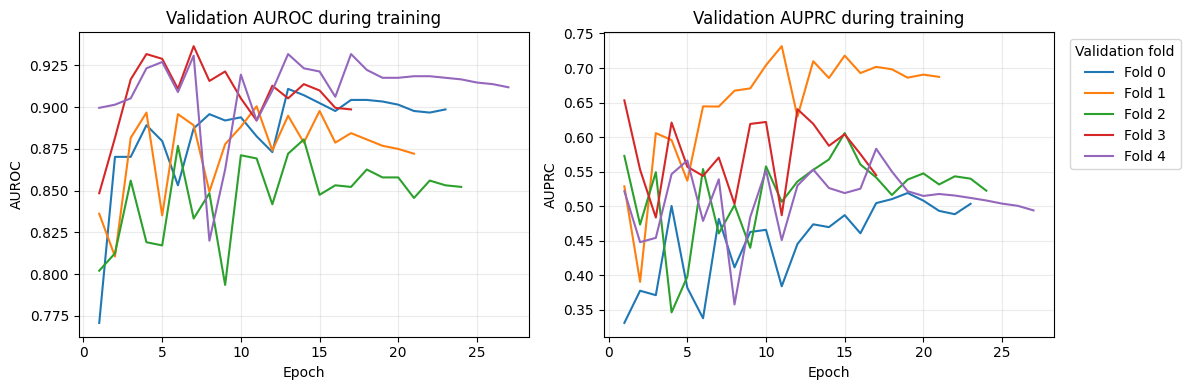

In [5]:
history_paths = [MODEL_DIR / f"fold_{fold}" / "history.csv" for fold in range(5)]
if all(path.is_file() for path in history_paths):
    figure, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False)
    for fold, path in enumerate(history_paths):
        history = pd.read_csv(path)
        axes[0].plot(history["epoch"], history["val_auroc"], label=f"Fold {fold}")
        axes[1].plot(history["epoch"], history["val_auprc"], label=f"Fold {fold}")
    axes[0].set(title="Validation AUROC during training", xlabel="Epoch", ylabel="AUROC")
    axes[1].set(title="Validation AUPRC during training", xlabel="Epoch", ylabel="AUPRC")
    for axis in axes:
        axis.grid(alpha=0.25)
    axes[1].legend(title="Validation fold", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Training curves will appear after all five models have been trained.")

## Fold-0 reproduction check

Replaying both saved models on the same 100 fold-0 validation patients confirmed that the original model scores higher:

| Model | AUROC | AUPRC | Best epoch |
|---|---:|---:|---:|
| Original notebook 2.1 | 0.9564 | 0.7686 | 23 |
| New fold-0 model | 0.9110 | 0.4739 | 13 |

Patient IDs, settings, starting weights, random states, and the first batch match in a setup check. One difference was found: the original and shared focal-loss code use mathematically equivalent formulas but produce slightly different gradients. This is a possible explanation, not a confirmed cause of the full drop. The saved histories already differ at epoch 1, so cutoff selection and averaging cannot explain this individual-model difference.

Keep both runs. The next diagnostic experiment should compare only the two loss calculations on fold 0, using development data and separate output folders. No retraining was done for this check. Historical software/hardware details are incomplete. See the [full audit and saved checks](../analysis_outputs/five_fold_cross_validation/ecg_fold0_audit/README.md).

## Community Test Set

Community-test patients are kept out of training. Evaluation measures performance on patients the models did not train on; it does not update model weights. Training settings, stopping points, and cutoffs are chosen using development data. Earlier notebooks have also reported results on this test set. If we use those test results to choose a model or plan changes, the test set also influences our decisions, even though it never updates the weights.

The next cell makes one probability from each of the five models for every community-test patient, averages those five values, and applies the cutoffs chosen from development predictions. It then compares the ensemble with the original single model.

Because the community test set has only five HFrEF patients, one changed HFrEF decision changes recall by 20 percentage points. The result should therefore be read carefully.

There is also a cutoff limitation: each development patient has a probability from one held-out model, while each test patient has an average from five models. Averaging can change the spread of the probabilities. For this reason, AUROC and AUPRC are the clearest comparison, and cutoff-based results are reported with this limitation.

In [6]:
evaluate_five_model_ensemble_on_test(
    PROJECT_ROOT,
    modality=MODALITY,
    seed=SEED,
    batch_size=BATCH_SIZE,
)
print(f"Community test results saved in: {RESULT_DIR}")

Community test results saved in: E:\Deep Learning\CardioFusion\analysis_outputs\five_fold_cross_validation\ecg_seed42


In [7]:
test_results_path = RESULT_DIR / "community_test_results.csv"
if test_results_path.is_file():
    test_results = pd.read_csv(test_results_path)
    test_columns = [
        "model", "cutoff_rule", "development_cutoff", "test_auroc", "test_auprc",
        "test_recall", "test_specificity", "test_balanced_accuracy",
        "test_precision", "test_f1", "test_brier", "test_calibration_error",
        "test_tn", "test_fp", "test_fn", "test_tp", "result_source",
    ]
    display(test_results[test_columns].round(4))

    ensemble_rows = test_results[test_results["model"].str.startswith("Five-model")]
    old_row = test_results[~test_results["model"].str.startswith("Five-model")].iloc[0]
    primary_ensemble = ensemble_rows[
        ensemble_rows["cutoff_rule"].eq("maximum_development_f1")
    ].iloc[0]
    print("Plain-language comparison using the cutoff fixed by development F1:")
    print(f"- Old model AUROC: {old_row.test_auroc:.3f}; five-model average AUROC: {primary_ensemble.test_auroc:.3f}.")
    print(f"- Old model AUPRC: {old_row.test_auprc:.3f}; five-model average AUPRC: {primary_ensemble.test_auprc:.3f}.")
    print(f"- Old model recall: {old_row.test_recall:.3f}; five-model average recall: {primary_ensemble.test_recall:.3f}.")
    print(f"- Old model specificity: {old_row.test_specificity:.3f}; five-model average specificity: {primary_ensemble.test_specificity:.3f}.")
else:
    print("Community test results have not been created.")

,model,cutoff_rule,development_cutoff,test_auroc,test_auprc,test_recall,test_specificity,test_balanced_accuracy,test_precision,test_f1,test_brier,test_calibration_error,test_tn,test_fp,test_fn,test_tp,result_source
0,Five-model ECG ensemble,maximum_development_f1,0.6120,0.9896,0.8600,0.6,1.0000,0.8000,1.0000,0.7500,0.0611,0.1943,115,0,2,3,five_model_probability_average
1,Five-model ECG ensemble,target_90pct_development_specificity,0.5658,0.9896,0.8600,0.8,0.9826,0.8913,0.6667,0.7273,0.0611,0.1943,113,2,1,4,five_model_probability_average
2,Original notebook 2.1 single model,original_saved_cutoff,0.5117,0.9983,0.9667,1.0,0.9652,0.9826,0.5556,0.7143,0.0238,0.0774,111,4,0,5,replayed_saved_checkpoint


Plain-language comparison using the cutoff fixed by development F1:
- Old model AUROC: 0.998; five-model average AUROC: 0.990.
- Old model AUPRC: 0.967; five-model average AUPRC: 0.860.
- Old model recall: 1.000; five-model average recall: 0.600.
- Old model specificity: 0.965; five-model average specificity: 1.000.


## Test classification reports and confusion matrices

The reports show the results for both five-model cutoffs and the original ECG model. The confusion matrices use rows for the true class and columns for the predicted class.


Five-model ECG ensemble | maximum_development_f1 | cutoff 0.6120
              precision    recall  f1-score   support

   Non-HFrEF     0.9829    1.0000    0.9914       115
       HFrEF     1.0000    0.6000    0.7500         5

    accuracy                         0.9833       120
   macro avg     0.9915    0.8000    0.8707       120
weighted avg     0.9836    0.9833    0.9813       120



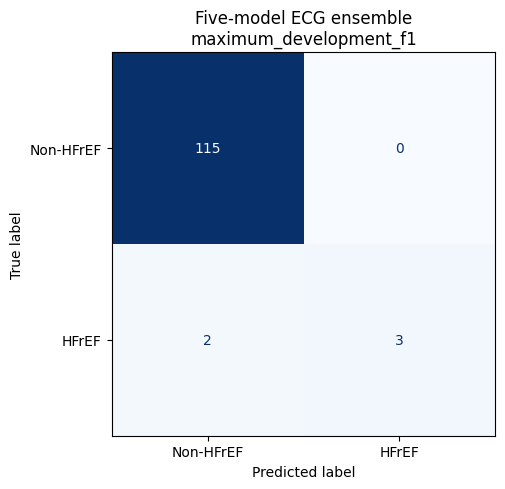


Five-model ECG ensemble | target_90pct_development_specificity | cutoff 0.5658
              precision    recall  f1-score   support

   Non-HFrEF     0.9912    0.9826    0.9869       115
       HFrEF     0.6667    0.8000    0.7273         5

    accuracy                         0.9750       120
   macro avg     0.8289    0.8913    0.8571       120
weighted avg     0.9777    0.9750    0.9761       120



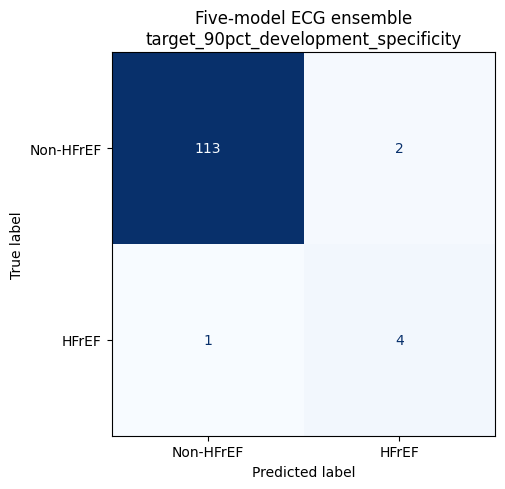


Original notebook 2.1 single model | original_saved_cutoff | cutoff 0.5117
              precision    recall  f1-score   support

   Non-HFrEF     1.0000    0.9652    0.9823       115
       HFrEF     0.5556    1.0000    0.7143         5

    accuracy                         0.9667       120
   macro avg     0.7778    0.9826    0.8483       120
weighted avg     0.9815    0.9667    0.9711       120



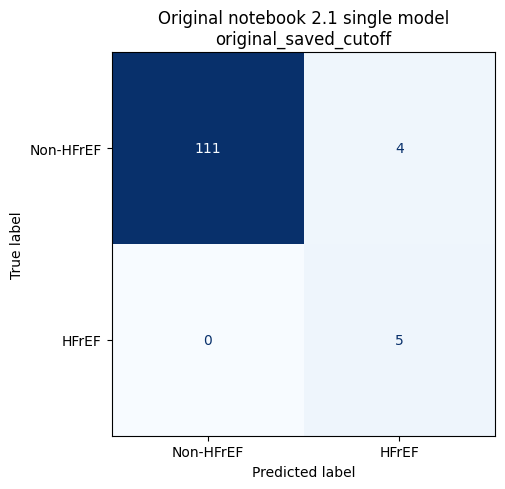

In [10]:
if test_results_path.is_file():
    for row in test_results.itertuples(index=False):
        tn, fp, fn, tp = (
            int(row.test_tn), int(row.test_fp),
            int(row.test_fn), int(row.test_tp),
        )
        true_labels = np.array([0] * (tn + fp) + [1] * (fn + tp))
        predictions = np.array([0] * tn + [1] * fp + [0] * fn + [1] * tp)
        matrix = np.array([[tn, fp], [fn, tp]])

        print(f"\n{row.model} | {row.cutoff_rule} | cutoff {row.development_cutoff:.4f}")
        print(classification_report(
            true_labels, predictions,
            labels=[0, 1],
            target_names=["Non-HFrEF", "HFrEF"],
            digits=4,
            zero_division=0,
        ))

        figure, axis = plt.subplots(figsize=(6, 5))
        ConfusionMatrixDisplay(
            confusion_matrix=matrix,
            display_labels=["Non-HFrEF", "HFrEF"],
        ).plot(ax=axis, cmap="Blues", colorbar=False, values_format="d")
        axis.set_title(f"{row.model}\n{row.cutoff_rule}")
        plt.tight_layout()
        plt.show()
else:
    print("Community test results have not been created.")

## How to decide what the result means

- A more reliable five-fold model should improve or at least preserve development AUROC and AUPRC across the folds, without depending on one unusually strong fold.
- On the community test, compare AUROC and AUPRC first. Then check recall, specificity, balanced accuracy, precision, and the exact counts of true and false decisions.
- A gain at only one cutoff is weaker evidence than a gain in AUROC and AUPRC.
- Large differences between folds mean the result is unstable and should not be treated as a clear improvement.
- If the five-model average does not clearly improve the old model, keep the old baseline for now and record this five-fold run as useful evidence.

These points are guidance for reading the tables. They are not results yet.

## Files made by this notebook

After training:

- Five `best_model.pt` files: one saved model for each validation fold.
- Five `history.csv` files: training loss, validation AUROC, and validation AUPRC by epoch.
- Five `validation_predictions.csv` files: the 100 held-out development predictions from each run.
- `development_oof_predictions.csv`: all 500 development predictions, one per patient.
- `development_summary.csv`: the combined development results and selected cutoffs.
- `fold_results.csv`: results shown separately for each fold.
- `run_settings.json`: settings and exact patient IDs used in every run.

After the separate community-test step:

- `community_test_fold_probabilities.csv`: each model's probability for each test patient.
- `community_test_ensemble_predictions.csv`: the averaged probability and decisions.
- `community_test_results.csv`: the ensemble and old-model comparison.

Large model files are ignored by Git. Result tables can be reviewed before deciding what belongs in a later commit.

## Draft notes to complete after running

- Did all five folds finish, and were any folds much weaker than the others?
- What did the combined development AUROC and AUPRC show?
- Which development cutoff gave the more useful recall and specificity balance?
- Did averaging five models improve the community test AUROC or AUPRC over the old model?
- How many of the five community-test HFrEF patients were found?
- Did the new method reduce false positives among non-HFrEF patients?
- Final choice: use the five-model average, keep the original single model, or collect more evidence.